### Import libraries

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

### Load dataset

In [91]:
df = pd.read_csv(r"C:\Users\anupa\Desktop\Python Learning\Cluster Analysis\Wholesale customers data.csv")

print(df.shape)
df.head()

(440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


### Missing value treatment

In [92]:
#Check missing values first

df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [93]:
#If missing values exist:

df = df.fillna(df.median(numeric_only=True))

### Exploratory Data Analysis (EDA)

#### Summary statistics

In [94]:

df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


#### Correlation heatmap

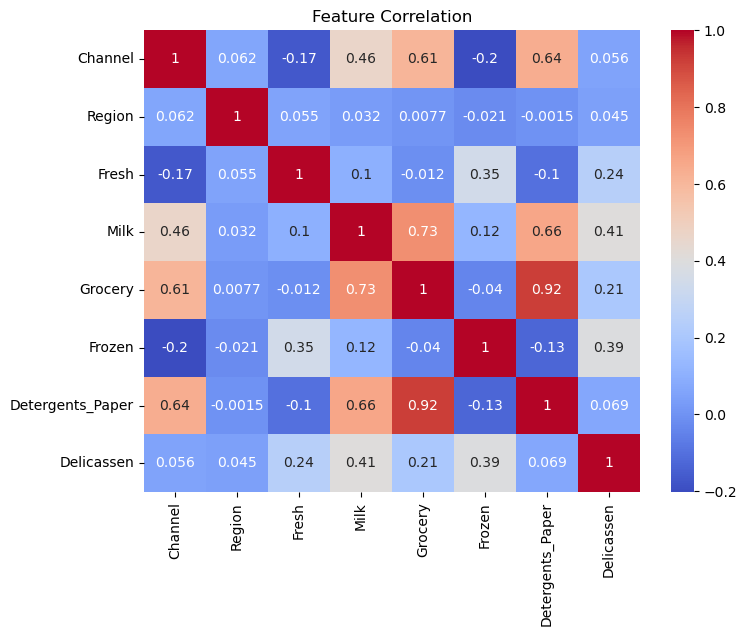

In [95]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

### Remove categorical columns

In [96]:
X = df.drop(['Channel','Region'], axis=1)

### Outlier detection (IQR method)

In [97]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)

IQR = Q3 - Q1

X = X[~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)]

In [98]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 332 entries, 0 to 439
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Fresh             332 non-null    int64
 1   Milk              332 non-null    int64
 2   Grocery           332 non-null    int64
 3   Frozen            332 non-null    int64
 4   Detergents_Paper  332 non-null    int64
 5   Delicassen        332 non-null    int64
dtypes: int64(6)
memory usage: 18.2 KB


### Train–test split 

In [99]:
X_train, X_test = train_test_split(
    X,
    test_size=0.3,
    random_state=42
)

### Feature scaling

In [100]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Elbow Method (optimal clusters)

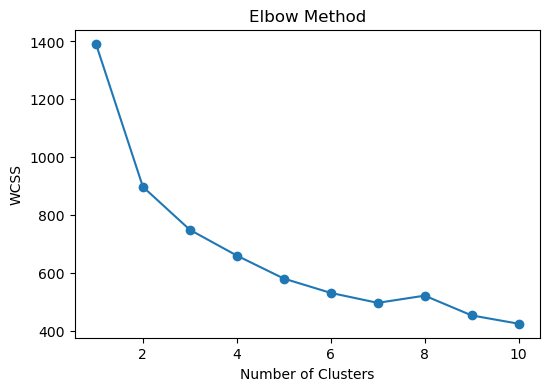

In [101]:
wcss = []

K_range = range(1,11)

for k in K_range:
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_scaled)
    
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

### Train clustering model

In [102]:
kmeans = KMeans(n_clusters=3, random_state=42)

train_clusters = kmeans.fit_predict(X_train_scaled)

### Cluster evaluation (Silhouette score) 

|Score | Quality |
|---|---|
|<0.25|	Poor|
|0.25–0.5|	Reasonable|
|>0.5|	Good|

In [103]:
sil_score = silhouette_score(X_train_scaled, train_clusters)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.26452635168485633


### Assign clusters to test data

In [104]:
test_clusters = kmeans.predict(X_test_scaled)

### Train XGBoost classifier

In [105]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train_scaled, train_clusters)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Predict clusters on test data

In [106]:
pred_clusters = model.predict(X_test_scaled)

### Model evaluation

In [107]:
accuracy = accuracy_score(test_clusters, pred_clusters)

print("Accuracy:", accuracy)

Accuracy: 0.93


### Confusion matrix

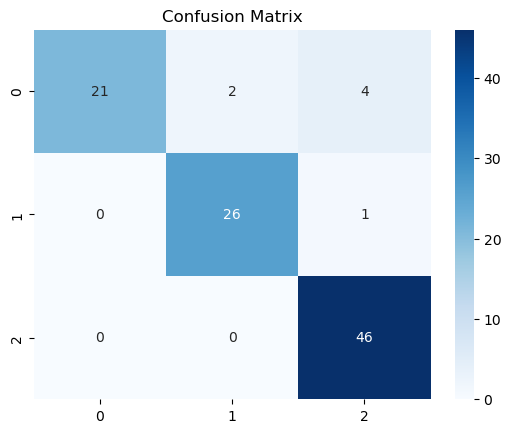

In [108]:
cm = confusion_matrix(test_clusters, pred_clusters)

sns.heatmap(cm, annot=True, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

### Classification report

In [109]:
print(classification_report(test_clusters, pred_clusters))

              precision    recall  f1-score   support

           0       1.00      0.78      0.88        27
           1       0.93      0.96      0.95        27
           2       0.90      1.00      0.95        46

    accuracy                           0.93       100
   macro avg       0.94      0.91      0.92       100
weighted avg       0.94      0.93      0.93       100



### PCA cluster visualization

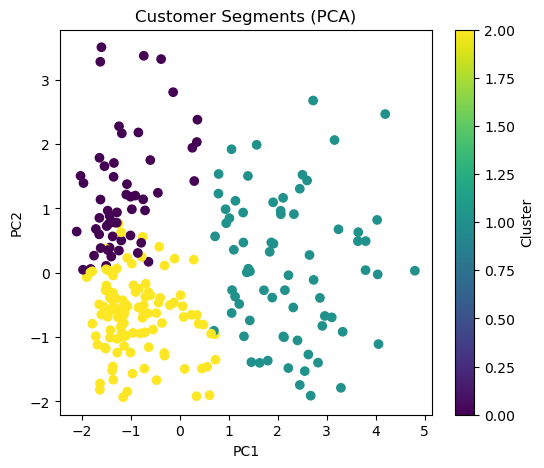

In [110]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(6,5))

plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=train_clusters,
    cmap='viridis'
)

plt.title("Customer Segments (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Cluster')
plt.show()

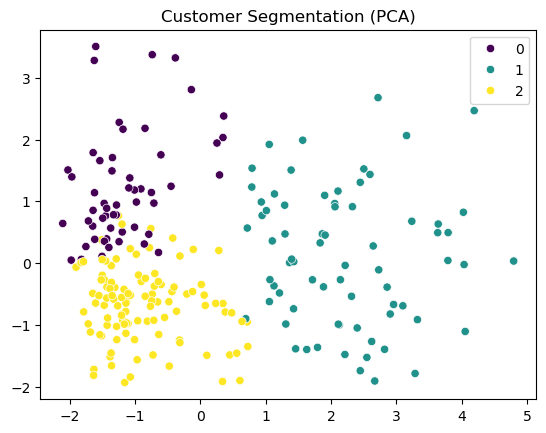

In [111]:
import seaborn as sns

sns.scatterplot(
    x=X_train_pca[:,0],
    y=X_train_pca[:,1],
    hue=train_clusters,
    palette='viridis'
)

plt.title("Customer Segmentation (PCA)")
plt.show()

### Cluster interpretation

Attach clusters back to original data.

In [112]:
X_train_clustered = X_train.copy()

X_train_clustered['Cluster'] = train_clusters

cluster_summary = X_train_clustered.groupby('Cluster').mean()

print(cluster_summary)

                Fresh         Milk       Grocery       Frozen  \
Cluster                                                         
0        15570.518519  2309.240741   3270.462963  3925.092593   
1         7710.746479  8107.929577  11834.408451  1439.239437   
2         7656.542056  2518.607477   2996.242991  1234.897196   

         Detergents_Paper   Delicassen  
Cluster                                 
0              477.888889  1209.685185  
1             4844.267606  1427.422535  
2              720.345794   616.504673  


Business interpretation.

Example:
Cluster 0 → Fresh product buyers
Cluster 1 → Grocery retailers
Cluster 2 → Balanced buyers